<a href="https://colab.research.google.com/github/KarenMaldonadoVasquez/P01---Behavioral-Finance/blob/main/p01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SIMULATOR TRADING RECORDS**



In [ ]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)

N = 1000

inversionistas = pd.DataFrame({
    "id": np.arange(1, N + 1),
    "delta": rng.uniform(0, 1, N),
    "kappa": rng.uniform(0, 1, N),
    "capital_inicial": rng.uniform(10_000, 500_000, N).round(2),
    "num_posiciones": rng.integers(5, 31, N)
})

print(inversionistas.head())
print(inversionistas.describe())


inversionistas.to_csv("inversionistas.csv", index=False)

   id     delta     kappa  capital_inicial  num_posiciones
0   1  0.773956  0.062063        422938.66              21
1   2  0.438878  0.458262        228730.85              26
2   3  0.858598  0.129030        476957.83              21
3   4  0.697368  0.152327        328889.35              20
4   5  0.094177  0.632283         66790.44              17
                id        delta        kappa  capital_inicial  num_posiciones
count  1000.000000  1000.000000  1000.000000      1000.000000     1000.000000
mean    500.500000     0.497178     0.508496    251507.988790       16.833000
std     288.819436     0.291586     0.289343    141890.009033        7.529263
min       1.000000     0.001233     0.000519     10485.100000        5.000000
25%     250.750000     0.240259     0.249506    129917.977500       10.000000
50%     500.500000     0.494824     0.496504    252767.795000       17.000000
75%     750.250000     0.758893     0.763053    375500.275000       23.000000
max    1000.000000    

Matrices de precios de acciones

In [ ]:
def simular_precios_factores(n_acciones=50, n_dias=500, precio_inicial=100.0, seed=42):
    rng = np.random.default_rng(seed)
    dt = 1 / 252

    mu_mkt = 0.08
    sigma_mkt = 0.16

    ret_mkt = (mu_mkt - 0.5 * sigma_mkt**2) * dt + sigma_mkt * np.sqrt(dt) * rng.normal(0, 1, n_dias)

    betas = rng.uniform(0.5, 1.5, n_acciones)
    sigmas_id = rng.uniform(0.10, 0.30, n_acciones)

    retornos_diarios = np.zeros((n_dias, n_acciones))

    for i in range(n_acciones):
        shocks_id = sigmas_id[i] * np.sqrt(dt) * rng.normal(0, 1, n_dias)
        retornos_diarios[:, i] = betas[i] * ret_mkt + shocks_id

    precios = np.zeros((n_dias + 1, n_acciones))
    precios[0, :] = precio_inicial

    for t in range(1, n_dias + 1):
        precios[t, :] = precios[t-1, :] * np.exp(retornos_diarios[t-1, :])

    columnas = [f"Stock_{i+1}" for i in range(n_acciones)]
    df_precios = pd.DataFrame(precios, columns=columnas)

    return df_precios

df_precios = simular_precios_factores(n_acciones=50, n_dias=500, seed=42)

print("Dimensiones de la matriz de precios:", df_precios.shape)
print(df_precios.head())

Dimensiones de la matriz de precios: (501, 50)
      Stock_1     Stock_2     Stock_3     Stock_4     Stock_5     Stock_6  \
0  100.000000  100.000000  100.000000  100.000000  100.000000  100.000000   
1   99.411079  102.196868  100.884159  101.704548  101.873090  102.886903   
2   99.894797  102.140198  100.137176   99.687240  101.344352  100.190523   
3  100.991998  103.909227  103.583592   97.133904   99.590821  105.030046   
4   98.837504  106.193488  102.929562  100.325687  101.762736  107.658304   

      Stock_7     Stock_8     Stock_9    Stock_10  ...    Stock_41  \
0  100.000000  100.000000  100.000000  100.000000  ...  100.000000   
1   99.913613  101.370160   99.889856  101.765496  ...   99.236847   
2   97.632131  101.463032   99.412907  103.506098  ...  100.502184   
3   96.409662  103.242198  101.304872  103.235500  ...  102.102338   
4   99.713767  104.140359  104.173678  103.102817  ...  104.439439   

     Stock_42    Stock_43    Stock_44    Stock_45    Stock_46    Stoc

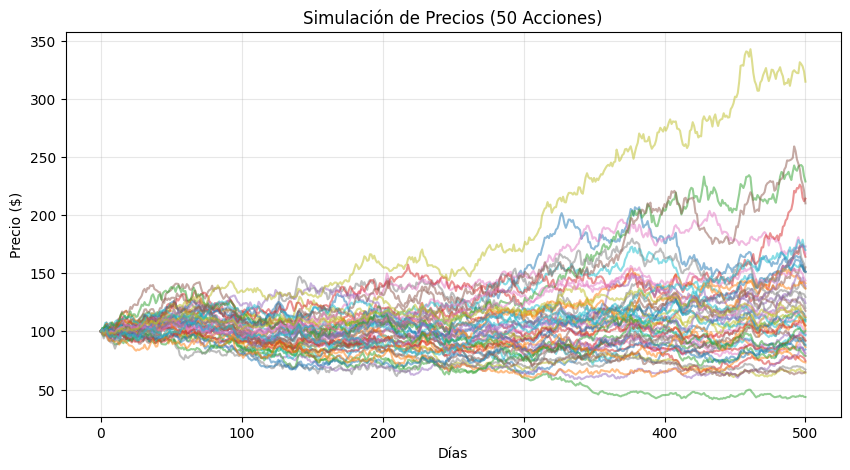

In [ ]:
import matplotlib.pyplot as plt

df_precios.plot(legend=False, figsize=(10, 5), alpha=0.5, title="Simulación de Precios (50 Acciones)")
plt.xlabel("Días")
plt.ylabel("Precio ($)")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:

rng = np.random.default_rng(42)
N = 1000

inversionistas = pd.DataFrame({
    "id": np.arange(1, N + 1),
    "delta": rng.uniform(0, 1, N),             # Efecto Disposición (mu)
    "kappa": rng.uniform(0, 1, N),             # Sobreconfianza (gamma)
    "capital_inicial": rng.uniform(10_000, 500_000, N).round(2),
    "num_posiciones": rng.integers(5, 31, N)
})

def simular_precios_factores(n_acciones=50, n_dias=500, precio_inicial=100.0, seed=42):
    rng_p = np.random.default_rng(seed)
    dt = 1 / 252  # Escala anual

    mu_mkt = 0.08
    sigma_mkt = 0.16

    # Factor de Mercado
    ret_mkt = (mu_mkt - 0.5 * sigma_mkt**2) * dt + sigma_mkt * np.sqrt(dt) * rng_p.normal(0, 1, n_dias)

    betas = rng_p.uniform(0.5, 1.5, n_acciones)
    sigmas_id = rng_p.uniform(0.10, 0.30, n_acciones)

    retornos_diarios = np.zeros((n_dias, n_acciones))

    for i in range(n_acciones):
        shocks_id = sigmas_id[i] * np.sqrt(dt) * rng_p.normal(0, 1, n_dias)
        retornos_diarios[:, i] = betas[i] * ret_mkt + shocks_id

    precios = np.zeros((n_dias + 1, n_acciones))
    precios[0, :] = precio_inicial

    for t in range(1, n_dias + 1):
        precios[t, :] = precios[t-1, :] * np.exp(retornos_diarios[t-1, :])

    columnas = [f"Stock_{i+1}" for i in range(n_acciones)]
    return pd.DataFrame(precios, columns=columnas)

df_precios = simular_precios_factores(n_acciones=50, n_dias=500, seed=42)


def crear_portafolio_inicial(df_inv, df_p, seed=42):
    rng_port = np.random.default_rng(seed)
    lista_acciones = list(df_p.columns)
    posiciones_iniciales = []

    for _, inv in df_inv.iterrows():
        id_inv = int(inv["id"])
        capital = inv["capital_inicial"]
        n_pos = int(inv["num_posiciones"])

        # Selección aleatoria de acciones para cada inversor
        acciones_elegidas = rng_port.choice(lista_acciones, size=n_pos, replace=False)
        capital_por_accion = capital / n_pos

        for accion in acciones_elegidas:
            precio_compra = df_p.loc[0, accion]  # $100.00 en Día 0
            titulos = capital_por_accion / precio_compra

            posiciones_iniciales.append({
                "id_inversor": id_inv,
                "accion": accion,
                "titulos": titulos,
                "precio_compra": precio_compra,  # Punto de referencia inicial
                "dia_compra": 0
            })

    return pd.DataFrame(posiciones_iniciales)

df_portafolio_dia0 = crear_portafolio_inicial(inversionistas, df_precios, seed=42)

df_precios.to_csv("precios_mercado.csv", index_label="Dia")
df_portafolio_dia0.to_csv("portafolio_inicial_dia0.csv", index=False)

## Precios de las Acciones (independiente)

In [ ]:
df_precios.head()

,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5,Stock_6,Stock_7,Stock_8,Stock_9,Stock_10,...,Stock_41,Stock_42,Stock_43,Stock_44,Stock_45,Stock_46,Stock_47,Stock_48,Stock_49,Stock_50
0,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
1,99.411079,102.196868,100.884159,101.704548,101.873090,102.886903,99.913613,101.370160,99.889856,101.765496,...,99.236847,101.560774,102.240225,99.190009,101.520948,100.684069,101.472488,99.866035,100.470335,102.600812
2,99.894797,102.140198,100.137176,99.687240,101.344352,100.190523,97.632131,101.463032,99.412907,103.506098,...,100.502184,98.843947,103.311680,99.150879,99.842005,100.879168,98.897276,97.727618,98.268532,99.957981
3,100.991998,103.909227,103.583592,97.133904,99.590821,105.030046,96.409662,103.242198,101.304872,103.235500,...,102.102338,98.356161,105.323647,99.681918,102.026067,101.261394,99.195191,99.019915,99.214306,101.898528
4,98.837504,106.193488,102.929562,100.325687,101.762736,107.658304,99.713767,104.140359,104.173678,103.102817,...,104.439439,96.760276,103.325654,102.083730,98.575211,101.121524,99.392055,99.407764,101.233360,102.874472


## Portafolio por inversionista (Inicial $S_0$)


In [ ]:
df_portafolio_dia0.head()

,id_inversor,accion,titulos,precio_compra,dia_compra
0,1,Stock_46,201.399362,100.0,0
1,1,Stock_36,201.399362,100.0,0
2,1,Stock_23,201.399362,100.0,0
3,1,Stock_24,201.399362,100.0,0
4,1,Stock_8,201.399362,100.0,0


## Trading cost

In [ ]:
def simular_trading_escenario(df_inv, df_port_0, df_precios, n_dias=5, p_base=0.10, comision_bps=10, spread_bps=20, seed=123):
    rng_trade = np.random.default_rng(seed)
    posiciones = df_port_0.copy()
    registro_ventas = []
    registro_papel = []

    mu_map = df_inv.set_index("id")["mu"].to_dict() if "id" in df_inv.columns else df_inv.set_index("id_inversor")["mu"].to_dict()
    gamma_map = df_inv.set_index("id")["gamma"].to_dict() if "id" in df_inv.columns else df_inv.set_index("id_inversor")["gamma"].to_dict()

    for dia in range(1, n_dias + 1):
        posiciones_activas = posiciones[posiciones["activa"]].copy() if "activa" in posiciones.columns else posiciones.copy()
        if "activa" not in posiciones.columns:
            posiciones["activa"] = True

        for idx, pos in posiciones_activas.iterrows():
            inv_id = int(pos["id_inversor"])
            acc = pos["accion"]
            precio_hoy = df_precios.loc[dia, acc]
            precio_ref = pos["precio_compra"]

            mu = mu_map[inv_id]
            gamma = gamma_map[inv_id]

            es_ganancia = precio_hoy > precio_ref
            freq_factor = 1.0 + 1.5 * gamma

            if es_ganancia:
                p_venta = p_base * (1.0 + mu) * freq_factor
            else:
                p_venta = p_base * (1.0 - mu) * freq_factor

            p_venta = min(max(p_venta, 0.0), 1.0)

            if rng_trade.random() < p_venta:
                posiciones.loc[idx, "activa"] = False
                p_venta_efectivo = precio_hoy * (1.0 - (spread_bps / 10000.0) / 2.0)
                monto_neto = pos["titulos"] * p_venta_efectivo * (1.0 - comision_bps / 10000.0)

                registro_ventas.append({
                    "dia": dia,
                    "id_inversor": inv_id,
                    "accion": acc,
                    "titulos": pos["titulos"],
                    "precio_compra": precio_ref,
                    "precio_venta_bruto": precio_hoy,
                    "monto_neto": monto_neto,
                    "tipo": "Realized Gain" if es_ganancia else "Realized Loss"
                })
            else:
                registro_papel.append({
                    "dia": dia,
                    "id_inversor": inv_id,
                    "accion": acc,
                    "precio_compra": precio_ref,
                    "precio_hoy": precio_hoy,
                    "tipo": "Paper Gain" if es_ganancia else "Paper Loss"
                })

    return pd.DataFrame(registro_ventas), pd.DataFrame(registro_papel)


def calcular_metricas_odean(df_v, df_p):
    rg = len(df_v[df_v["tipo"] == "Realized Gain"]) if len(df_v) > 0 else 0
    rl = len(df_v[df_v["tipo"] == "Realized Loss"]) if len(df_v) > 0 else 0
    pg = len(df_p[df_p["tipo"] == "Paper Gain"]) if len(df_p) > 0 else 0
    pl = len(df_p[df_p["tipo"] == "Paper Loss"]) if len(df_p) > 0 else 0

    pgr = rg / (rg + pg) if (rg + pg) > 0 else 0.0
    plr = rl / (rl + pl) if (rl + pl) > 0 else 0.0

    return {
        "RG": rg,
        "PG": pg,
        "RL": rl,
        "PL": pl,
        "PGR": round(pgr, 4),
        "PLR": round(plr, 4),
        "PGR-PLR": round(pgr - plr, 4)
    }

**Scenarios nones: Both estimators quiet 1,3,5**


In [ ]:
# 1. Seleccionamos los primeros 10 inversores y 5 días de precios
df_inv_mini = inversionistas.iloc[0:10].copy()
df_port_0_mini = df_portafolio_dia0[df_portafolio_dia0["id_inversor"].isin(df_inv_mini["id"])].copy()
df_precios_mini = df_precios.iloc[0:6].copy()  # Día 0 al Día 5

# 2. Definimos la simulación para los 3 primeros escenarios
escenarios_prueba = {
    "Escenario 1 (Caso Nulo: mu=0, gamma=0)": (0.0, 0.0),
    "Escenario 3 (Disposición Alta: mu=0.8, gamma=0)": (0.8, 0.0),
    "Escenario 5 (Sobreconfianza Alta: mu=0, gamma=0.8)": (0.0, 0.8)
}

resultados_tabla = []

for nombre, (mu_val, gamma_val) in escenarios_prueba.items():
    # Asignamos los parámetros del escenario
    df_inv_esc = df_inv_mini.copy()
    df_inv_esc["mu"] = mu_val
    df_inv_esc["gamma"] = gamma_val

    # Ejecutamos la simulación diaria
    df_v, df_p = simular_trading_escenario(
        df_inv=df_inv_esc,
        df_port_0=df_port_0_mini,
        df_precios=df_precios_mini,
        n_dias=5,
        p_base=0.10,
        seed=123
    )

    # Calculamos las métricas de Odean (1998)
    metricas = calcular_metricas_odean(df_v, df_p)
    metricas["Escenario"] = nombre
    resultados_tabla.append(metricas)

# 3. Convertimos a DataFrame e IMPRIMIMOS los resultados
df_resumen = pd.DataFrame(resultados_tabla)
col_orden = ["Escenario", "RG", "PG", "RL", "PL", "PGR", "PLR", "PGR-PLR"]
df_resumen = df_resumen[col_orden]

print("=== TABLA DE COMPROBACIÓN DE RESULTADOS (ODEAN, 1998) ===")
print(df_resumen.to_string(index=False))

=== TABLA DE COMPROBACIÓN DE RESULTADOS (ODEAN, 1998) ===
                                         Escenario  RG  PG  RL  PL    PGR    PLR  PGR-PLR
            Escenario 1 (Caso Nulo: mu=0, gamma=0)  34 334  32 279 0.0924 0.1029  -0.0105
   Escenario 3 (Disposición Alta: mu=0.8, gamma=0)  53 289   7 324 0.1550 0.0211   0.1338
Escenario 5 (Sobreconfianza Alta: mu=0, gamma=0.8)  54 229  55 188 0.1908 0.2263  -0.0355


**Ejercicios pares 2,4,6**





In [ ]:
# Código para correr únicamente los Escenarios 2, 4 y 6
escenarios_3 = {
    "Escenario 2 (Disposición Baja: mu=0.3, gamma=0)": (0.3, 0.0),
    "Escenario 4 (Sobreconfianza Baja: mu=0, gamma=0.3)": (0.0, 0.3),
    "Escenario 6 (Ambos Activos: mu=0.8, gamma=0.8)": (0.8, 0.8)
}

resultados_3 = []

for nombre, (mu_val, gamma_val) in escenarios_3.items():
    # Asignamos los parámetros del escenario
    df_inv_esc = df_inv_mini.copy()
    df_inv_esc["mu"] = mu_val
    df_inv_esc["gamma"] = gamma_val

    # Ejecutamos la simulación diaria
    df_v, df_p = simular_trading_escenario(
        df_inv=df_inv_esc,
        df_port_0=df_port_0_mini,
        df_precios=df_precios_mini,
        n_dias=5,
        p_base=0.10,
        seed=123
    )

    # Calculamos las métricas de Odean (1998)
    metricas = calcular_metricas_odean(df_v, df_p)
    metricas["Escenario"] = nombre
    resultados_3.append(metricas)

# Convertimos a DataFrame e imprimimos
df_resumen_3 = pd.DataFrame(resultados_3)
col_orden = ["Escenario", "RG", "PG", "RL", "PL", "PGR", "PLR", "PGR-PLR"]

print("=== RESULTADOS DE LOS ESCENARIOS 2, 4 Y 6 ===")
print(df_resumen_3[col_orden].to_string(index=False))

=== RESULTADOS DE LOS ESCENARIOS 2, 4 Y 6 ===
                                         Escenario  RG  PG  RL  PL    PGR    PLR  PGR-PLR
   Escenario 2 (Disposición Baja: mu=0.3, gamma=0)  39 327  21 305 0.1066 0.0644   0.0421
Escenario 4 (Sobreconfianza Baja: mu=0, gamma=0.3)  45 291  39 260 0.1339 0.1304   0.0035
    Escenario 6 (Ambos Activos: mu=0.8, gamma=0.8) 100 142  11 260 0.4132 0.0406   0.3726


**Intepretación**

**Escenario 2:** Vemos que el escenario es de disposición baja ya que nuestro mu = 0.3 y nuestra gamma = 0, por lo que podemos analizar que un inversionista estaría más dispuesto a vender , por ejemplo algo que compro a 100 si es que el precio llega a 105, que si es que baja a 95. Analizamos que la conducta llega a ser hacia una inclinación moderada de las decisiones propias.


**Escenario 4:** Durante este escenario nos dice que hay una sobreconfianza baja, utilizamos un mu de 0 y una gamma de 0.3, ya que podemos ver que el comportamiento es vender más sin tener algún tipo de preferencia programada por algún tipo de ganancia. Vemos que hay más actividad aunque la idea principal es que el inversionista se limita a vender lo que ya tenía y no se simula nuevas compras.


**Escenario 6:** Aquí ya usamos ambos activos, usamos una mu de 0.8 y una gamma de 0.8, por lo que podemos analizar que el comportamiento es dirigido a mucha actividad y una fuerte preferencia por vender ganadoras. Vemos que se combinan disposición alta y una sobreconfianza alta. Existe mucha separación por lo que la disposición dirige las ventas hacia las acciones ganadoras, la sobreconfianza aumenta la frecuencia de estas decisiones. Y aunque vemos que las ventas totales son parecidas, aquí la composición cambia mucho, ya que casi todas las ventas son de inversiones ganadoras.


**Ejercicios 7 y 8**


In [ ]:
def simular_confusores(df_port_0, df_precios, n_dias=5, seed=123):

    rng7 = np.random.default_rng(seed)
    pos7 = df_port_0.copy()
    pos7["activa"] = True
    v7, p7 = [], []

    for dia in range(1, n_dias + 1):
        for idx, pos in pos7[pos7["activa"]].iterrows():
            inv_id, acc, precio_ref = int(pos["id_inversor"]), pos["accion"], pos["precio_compra"]
            precio_hoy = df_precios.loc[dia, acc]
            es_ganancia = precio_hoy > precio_ref

            p_venta = 0.25 if es_ganancia else 0.05

            if rng7.random() < p_venta:
                pos7.loc[idx, "activa"] = False
                v7.append({
                    "dia": dia,
                    "id_inversor": inv_id,
                    "accion": acc,
                    "tipo": "Realized Gain" if es_ganancia else "Realized Loss"
                })
            else:
                p7.append({
                    "dia": dia,
                    "id_inversor": inv_id,
                    "accion": acc,
                    "tipo": "Paper Gain" if es_ganancia else "Paper Loss"
                })

    rng8 = np.random.default_rng(seed)
    pos8 = df_port_0.copy()
    pos8["activa"] = True
    v8, p8 = [], []

    for dia in range(1, n_dias + 1):
        for idx, pos in pos8[pos8["activa"]].iterrows():
            inv_id, acc, precio_ref = int(pos["id_inversor"]), pos["accion"], pos["precio_compra"]
            precio_hoy = df_precios.loc[dia, acc]
            es_ganancia = precio_hoy > precio_ref

            p_venta = 0.28 if es_ganancia else 0.03

            if rng8.random() < p_venta:
                pos8.loc[idx, "activa"] = False
                v8.append({
                    "dia": dia,
                    "id_inversor": inv_id,
                    "accion": acc,
                    "tipo": "Realized Gain" if es_ganancia else "Realized Loss"
                })
            else:
                p8.append({
                    "dia": dia,
                    "id_inversor": inv_id,
                    "accion": acc,
                    "tipo": "Paper Gain" if es_ganancia else "Paper Loss"
                })

    return pd.DataFrame(v7), pd.DataFrame(p7), pd.DataFrame(v8), pd.DataFrame(p8)

def calcular_metricas(df_v, df_p):
    rg = len(df_v[df_v["tipo"] == "Realized Gain"]) if len(df_v) > 0 else 0
    rl = len(df_v[df_v["tipo"] == "Realized Loss"]) if len(df_v) > 0 else 0
    pg = len(df_p[df_p["tipo"] == "Paper Gain"]) if len(df_p) > 0 else 0
    pl = len(df_p[df_p["tipo"] == "Paper Loss"]) if len(df_p) > 0 else 0

    pgr = rg / (rg + pg) if (rg + pg) > 0 else 0.0
    plr = rl / (rl + pl) if (rl + pl) > 0 else 0.0

    return {
        "RG": rg,
        "PG": pg,
        "RL": rl,
        "PL": pl,
        "PGR": round(pgr, 4),
        "PLR": round(plr, 4),
        "PGR-PLR": round(pgr - plr, 4)
    }

v7, p7, v8, p8 = simular_confusores(df_port_0_mini, df_precios_mini, n_dias=5, seed=123)

m7 = calcular_metricas(v7, p7)
m7["Escenario"] = "Escenario 7 (Confusor Rebalanceo: mu=0, gamma=0)"

m8 = calcular_metricas(v8, p8)
m8["Escenario"] = "Escenario 8 (Confusor Reversión a la Media: mu=0, gamma=0)"

df_resumen_confusores = pd.DataFrame([m7, m8])
col_orden = ["Escenario", "RG", "PG", "RL", "PL", "PGR", "PLR", "PGR-PLR"]

print("RESULTADOS DE LOS ESCENARIOS 7 Y 8 (CONFUSORES)")
print(df_resumen_confusores[col_orden].to_string(index=False))

RESULTADOS DE LOS ESCENARIOS 7 Y 8 (CONFUSORES)
                                                 Escenario  RG  PG  RL  PL    PGR    PLR  PGR-PLR
          Escenario 7 (Confusor Rebalanceo: mu=0, gamma=0)  66 242  16 295 0.2143 0.0514   0.1628
Escenario 8 (Confusor Reversión a la Media: mu=0, gamma=0)  78 207   7 300 0.2737 0.0228   0.2509


**Interpretación 7:rebalanceo**: tiene un mu de 0 (sin disposición) que le asignó al inicio, no tiene sesgo de perder o ganar y si una acción esta en ganancia se vende una parte por precaucióon y aún así dió positivo (Odean PGR-PLR positivo), entonces vender una ganadora por precaución que por sesgo (no se puede diferenciar con el detector si es por la diversificación o una dispocisión)
**Interpretación 8: reversión de media**: con psicología de que sube y luego baja o con miedo al futuro con mu en 0 y resulta en un PGR-PLR positivo con una dispocisión ahora si.

Esto nos dice que el detector no es confiable porque no nos dice verdaderamente el sesgo psicológico, que está pasando dentro del inversionista. Por esa cuestión sería necesario ver el verdadero efecto de dispocisiones.